#### MA124 Maths by Computer
# Project: Modelling in Epidemiology

#### Background
Epidemiological models are increasingly used during infectious disease outbreaks to make outbreak projections and to guide control interventions. This project involves developing simple computational models of outbreaks and using them to predict the effects of different interventions. It also involves using stochastic epidemiological models (models that include randomness) to predict the risk that early cases at the beginning of an outbreak lead on to a major epidemic (with a large number of cases) as opposed to fade out as a minor outbreak (with a small number of cases). 

If more details are required about the background epidemiological modelling theory, please rewatch the Epidemiology Lecture, available on the MA124 moodle page.

#### Structure of project
There are six tasks in the document below, tasks A1-A5 and then task B1. Your group should do all six of these tasks. Tasks A1-A5 are worth approximately 60% of the credit for this submission and task B1 is worth the rest (approximately 40%).

#### Notes about submission
Read through the document **MA124 Maths by Computer Tutor Group Projects Information for Students.pdf** on the MA124 Moodle page.

Before submitting see the notes at the end of this document.

#### Allowed libraries for this project 
Python libraries/modules should be used as required to complete the tasks in this project, with no restrictions.

## Section A (worth approximately 60% of the marks)

## The Deterministic SIR model

In the Epidemiology lecture, you met the deterministic SIR model given by a system of three ODEs.

This part of the assignment builds on the "Epidemiology I code" notebook, which provides code for numerically solving the SIR model in Python. We are interested in extensions to the SIR model as presented there: specifically, extensions involving public health measures such as vaccination and social distancing.

Note: You are expected to add code and markdown cells to this document as appropriate to provide your responses to the tasks. However, throughout this assignment, please do use the deterministic and stochastic SIR model codes from the Epidemiology I and Epidemiology II code notebooks as required (i.e., you are supposed to copy that code across and adapt it, rather than start coding from scratch).

---

## Task A1. Baseline case (worth approximately 12% of the marks)
**Assignment:** Using Python, solve the deterministic SIR model numerically and examine the solution for one set of parameter values and one initial condition. Then, adapt the code to rerun the analysis multiple times for different infection rates.

Details: 
- Use the following parameter values for the baseline case (where, throughout this Assignment, time is measured in days): $\beta = 2 \times 10^{-5}$, $\mu = 0.1$, $N = 10^{4}$.
- Initiate the numerical solution starting with 3 infected individuals, with the remainder of the population susceptible.
- Produce two plots: a time-series showing $S(t)$, $I(t)$ and $R(t)$ and a phase plane (in the $(S,I)$ plane).
- On both plots, indicate the point on the trajectory where $I$ reaches its maximum as black circles, and print this maximum value (when you print the value, round this value to the largest integer that is less than this value).
- Now repeat this analysis a large number of times for different values of $\beta$ (without generating a figure each time; so as to not generate a huge number of figures!) Plot the maximum value of $I$ as a function of $\beta$, choosing an appropriate range of values of $\beta$ (and sufficiently many values) to be able to see the dependence clearly.

Hint: You might like to Google the appropriate NumPy function that finds the maximum value in a vector. For the last part, use a FOR loop rather than changing the value of $\beta$ manually.

Once you have completed this, you might like to help your team member who is doing Task A4 below!

*Insert code and markdown cells below, as appropriate, in which to provide your response to this task.*

---

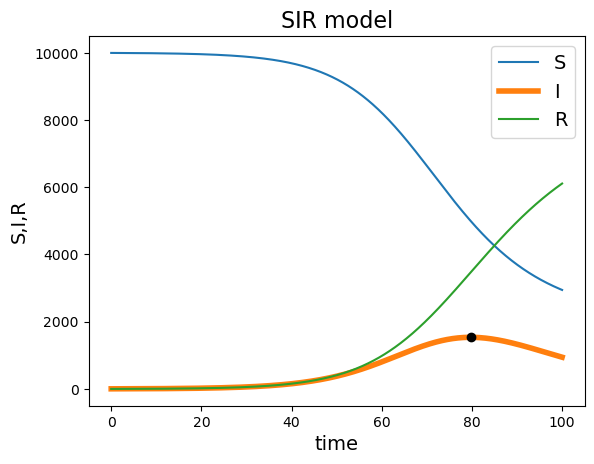

Text(0.5, 1.0, 'Phase plane for SIR model')

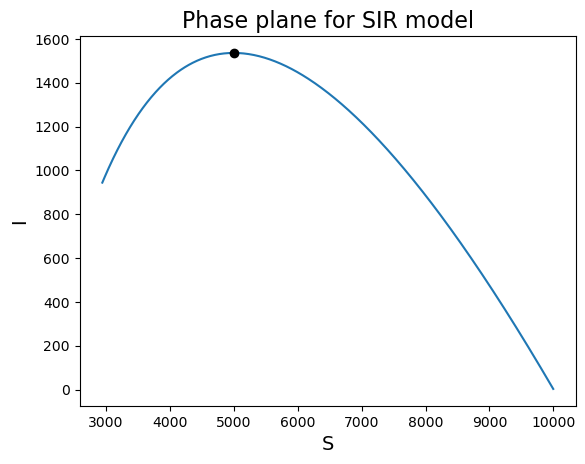

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint 

# Define the ODE

def SIR(y, t, beta, mu):
    # returns RHS of the SIR model
    S, I, R = y
    N = S + I + R
    Sdot = -beta * S * I
    Idot = beta * S * I - mu * I
    Rdot = mu * I
    
    return Sdot, Idot, Rdot

# Problem setup/parameters

tf = 100
Nsteps = 1000
t = np.linspace(0, tf, Nsteps+1)

# Set initial conditions and put into array y0
S0 = 10**4 - 3
I0 = 3
R0 = 0
y0 = np.array([S0, I0, R0])

beta = 2*(10**-5)
mu = 0.1

# Solve for the given beta

y_sol = odeint(SIR, y0, t, args=(beta, mu))
S = y_sol[:,0]
I = y_sol[:,1]
R = y_sol[:,2]

# Find max of I 
idx_max = np.argmax(I)
t_max = t[idx_max]
S_at_max = S[idx_max]
I_max = I[idx_max]
I_max_floor = int(np.floor(I_max))

# Plots

# plot the time evolution of the S, I, R
plt.plot(t, S, label = "S")
plt.plot(t, I, lw = 4, label = "I")
plt.plot(t, R, label = "R")
plt.plot(t_max, I_max, "ko")

# labels etc
plt.xlabel("time", fontsize = 14)
plt.ylabel("S,I,R", fontsize = 14)
plt.title("SIR model", fontsize = 16)
plt.legend(fontsize = 14)
plt.show()

# plot the evolution in the S,I phase plane
plt.plot(S, I)
plt.plot(S_at_max, I_max, "ko")

# labels etc
plt.xlabel("S", fontsize = 14)
plt.ylabel("I", fontsize = 14)
plt.title("Phase plane for SIR model", fontsize = 16)


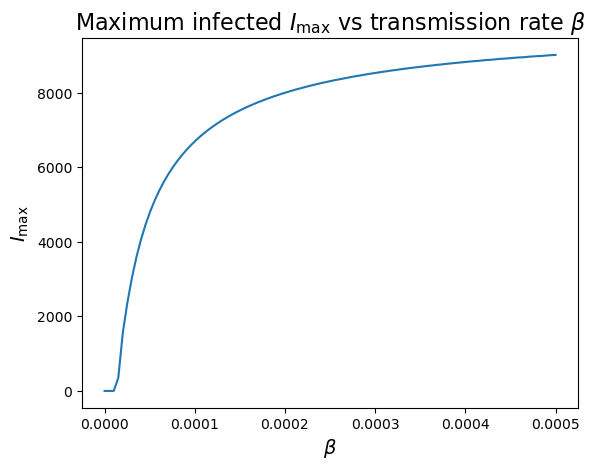

In [2]:
beta_vals = np.linspace(0.0, 5*10**-4, 100)   # "sufficiently many" + reasonable range
Imax_vals = np.zeros_like(beta_vals)

for k, b in enumerate(beta_vals):
    y_tmp = odeint(SIR, y0, t, args=(b, mu))
    I_tmp = y_tmp[:, 1]
    Imax_vals[k] = np.max(I_tmp)

# One final figure
plt.figure()
plt.plot(beta_vals, Imax_vals)
plt.xlabel(r"$\beta$", fontsize=14)
plt.ylabel(r"$I_{\max}$", fontsize=14)
plt.title(r"Maximum infected $I_{\max}$ vs transmission rate $\beta$", fontsize=16)
plt.show()

## Task A2. The effect of vaccination (worth approximately 12% of the marks)
**Assignment:** Using Python, solve the deterministic SIR model numerically for different numbers of individuals vaccinated. 

Details:
- Use the following parameter values for the baseline case: $\beta = 2 \times 10^{-5}$, $\mu = 0.1$, $N = 10^{4}$.
- Assume that each simulation starts with 5 infected individuals (with the remainder of the population susceptible, other than those who have been vaccinated).
- Assume that vaccination involves simply withdrawing susceptible individuals from the population (to a new $V$ compartment, which is different to the removed ($R$) compartment) instantaneously at the start of the numerical simulation, and that vaccination is perfectly effective.
- Make a plot of the total number of individuals who are either infected or removed (i.e., $I+R$) after 500 days as a function of the number of vaccinated hosts. Hint: This will require running the SIR model multiple times (once for each value of the number of vaccinated individuals, $V$) using a FOR loop.
- Add markers to the plot corresponding to the (strictly positive) numerical solution of the final size equation (explained in the Lecture and below), in which $N$ is simply reduced by $V$, for values of i) $V = 1000$; ii) $V = 2000$; iii) $V = 3000$.
- Include a derivation of the final size equation in your answer to this task.

- Hint: Recall that the final size equation is $x = N - N \rm{exp} \left( -\frac{\beta x}{\mu} \right)$ in a scenario without vaccination (vaccination then corresponds to reducing the value of $N$). You will have to look up an appropriate Python function to solve this equation numerically. To find the strictly positive solution (rather than the solution $x = 0$) numerically, a sufficiently large "initial guess" may need to be input to the relevant Python function.

*Insert code and markdown cells below, as appropriate, in which to provide your response to this task.*

---

Deriving final size equation. 
We want to find the total number of people who have been infected after a certain time, $t$. 
So we care about the number of infected people as a function of the susceptible population.
We know from the model 
$$\frac{dS}{dt} = -\beta IS$$
$$\frac{dI}{dt} =  \beta IS - \mu I$$
We can apply chain rule to obtain $\frac{dI}{dS}$.
$$\frac{dI}{dS} = -1 + \frac{\mu}{\beta S}$$
This is a seperable DE so we can integrate both sides to obtain
$$I = -S +\frac{\mu}{\beta}\ln(S) + C$$
where $C$ is a constant.
To solve for C we can use our initial values from the model.
$$I_0 + S_0 - \frac{\mu}{\beta}\ln(S_0) = C$$
By assumption, no one is removed at the start so $I_0 + S_0 = N$. This means we can simplify our constant value. Moving back to the whole equation
$$I = -S +\frac{\mu}{\beta}\ln(S) + N - \frac{\mu}{\beta}\ln(S_0)$$
Since we want the final size we want to consider the limit of this as $t \to \infty$. We know $I(t) \to 0$ and thus $S(t) + R(t) = N$
$$0 = R(t) +\frac{\mu}{\beta}\ln\left(\frac{N - R(t)}{S_0}\right)$$
We can rearrange to solve for $R(t)$
$$\frac{N - R(t)}{S_0} = e^{-\frac{\beta R(t)}{\mu}} $$
$$R(t) = N - S_0e^{-\frac{\beta R(t)}{\mu}} $$
In our case $S_0$ is very close to $N$, so we can write 
$$R(t) = N - Ne^{-\frac{\beta R(t)}{\mu}} $$

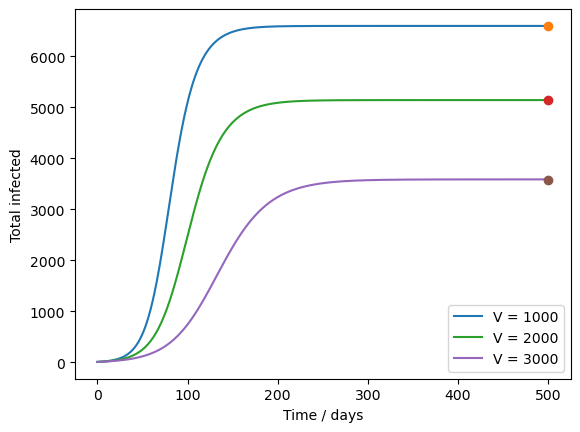

In [3]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# initial population  
N = 1e4

def final_size_eq(x, V, N, beta, mu):
    # in this case susceptible population is N-V not N and x is going to be R(inf)
    return N-V - x - (N - V)*np.exp(-beta*x/mu)

def SIR(y, t):
    # returns RHS of the SIR model
    S, I, R, V = y
    beta = 2e-5
    mu = 0.1

    N = S + I + R + V

    Sdot = -beta * S * I
    Idot = beta * S * I - mu * I
    Rdot = mu * I
    Vdot = 0
    return Sdot, Idot, Rdot, Vdot


for V in [1000,2000,3000]:
    # initial values
    S0, I0, R0, V0 = N - 5 - V, 5, 0, V

    times = np.arange(0,500,1)
    sol = odeint(SIR, y0=[S0,I0,R0,V0], t=times)

    S = sol.T[0]
    I = sol.T[1]
    R = sol.T[2]
    plt.plot(times, I + R, label=f"V = {V}")

    # we choose x0 to be N-V as max number of possible infected
    x_sol = fsolve(final_size_eq, x0=N-V, args=(V,N,2e-5,0.1)) 
    plt.plot(500, x_sol, 'o')
plt.legend()
plt.xlabel("Time / days")
plt.ylabel("Total infected")
plt.show()

## Task A3. The effect of social distancing (worth approximately 12% of the marks)

The introduction and/or removal of social distancing can be modelled by varying the infection rate parameter, $\beta$. In this exercise, we will use the following time-dependent infection rate parameter:

$$
\beta(t)  = 2 \times 10^{-7} \text{  whenever  } t < T, \\
\beta(t)  = 1.5 \times 10^{-7} \text{  whenever  } T \le t \le T + 30, \\
\beta(t)  = 2 \times 10^{-7} \text{  whenever  } t > T + 30. \\
$$

**Assignment:** Using Python, run the deterministic SIR model for the social distancing strategy described above.

Details:
- For this task, use the values $\mu = 0.1$, $N = 10^{6}$, and assume that the initial values of $(S,I,R)$ are $(N-5,5,0)$.
- Run the SIR model, adapted according to the time-dependent value of $\beta$ described above, for a value of $T = 30$ days. Plot a time-series showing $S(t)$, $I(t)$ and $R(t)$.
- Consider a scenario in which $T$ is not necessarily 30 days, and can instead take a fixed integer value between 1 and 200 days. Write a FOR loop to identify the value of $T$ that minimises the maximum value of $I$ in the model simulation. Plot the maximum value of $I$ as a function of $T$, and print the value of $T$ that "flattens the curve" most.

*Insert code and markdown cells below, as appropriate, in which to provide your response to this task.*

---

The deterministic SIR model is given by the following system of ordinary differential equations:

$$
\frac{{\rm d} S}{{\rm d} t}  = - \beta S I, \quad 
\frac{{\rm d} I}{{\rm d} t}  = \beta S I - \mu I, \quad 
\frac{{\rm d} R}{{\rm d} t}  = \mu I.
$$

In these equations, $S$ is the number of susceptible individuals, $I$ is the number of infectious individuals, $R$ is the number of removed individuals (recovered and immune, or dead). $N$ is the total number of individuals, where $N = S+I+R$. By adding the three equations, it can be verified that $\frac{d N}{d t} = 0$, and so $N$ is constant. The variables $\beta$ and $\mu$ are model parameters: $\beta$ is the infection rate parameter, $\mu$ is the removal rate parameter (the reciprocal of the expected time for which an infected individual remains infectious).

As shown in the Epidemiology lecture, the basic reproduction number is given by
$ R_0 = \frac{\beta N}{\mu}. $

The Python code cells below compute numerical solutions to this model by calling the SciPy ODE solver odeint. 

Results are shown for specific parameter values: $ N=10^5$, $\beta = 3 \times 10^{-6}$ and $\mu = 0.1$, corresponding to $R_0 = 3$. The initial conditions are $S(0) = N - 5$, $I(0) = 5$, and $R(0) = 0$. So, we start with only 5 infectious individuals.

In [4]:
# import libraries

import numpy as np # Import NumPy library. The "np" bit tells Python to give NumPy the alias of np. So now we can call np. function_name rather than numpy.
import matplotlib.pyplot as plt
from scipy.integrate import odeint 

In [5]:
# --- First define the RHS of ODE system --- #

def SIR(y, t, T):
    # returns RHS of the SIR model
    # parameter T determines start of 30-day lockdown period
    S, I, R = y

    # infection rate parameter beta is reduced during lockdown period
    if T < t < T+30:
        beta = 1.5*(10**-7)
    else: 
        beta = 2*(10**-7)
    mu = 0.1
    
    N = S + I + R
    Sdot = -beta * S * I
    Idot = beta * S * I - mu * I
    Rdot = mu * I
    
    return Sdot, Idot, Rdot

In [6]:
# --- Problem setup --- #

# set up time grid for the solution
tf = 500
Nsteps = 1000
t = np.linspace(0, tf, Nsteps+1)

# Set initial conditions and put into array y0
S0 = 10**6 - 5
I0 = 5
R0 = 0
y0 = np.array([S0, I0, R0])

In [7]:
# --- Call the ODE solver and extract solutions for T=30 --- #
  
y_sol = odeint(SIR, y0, t, args=(30,))

# extract S, I, R from the solution array y
S = y_sol[:,0]
I = y_sol[:,1]
R = y_sol[:,2]

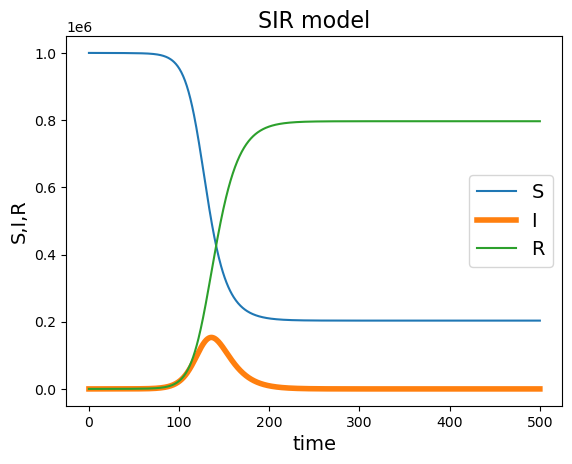

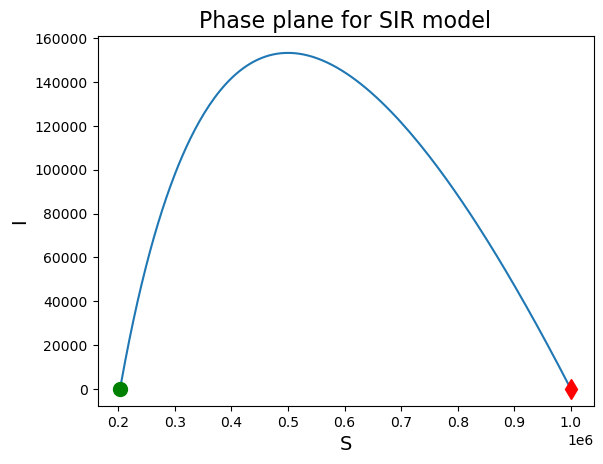

At the end of the simulation, the final values of S, I, and R are (rounded):
S(t=tf) = 203306
I(t=tf) = 0
R(t=tf) = 796694


In [8]:
# --- Plot for T=30 --- #

# plot the time evolution of the S, I, R
plt.plot(t, S, label = "S")
plt.plot(t, I, lw = 4, label = "I")
plt.plot(t, R, label = "R")

# labels etc
plt.xlabel("time", fontsize = 14)
plt.ylabel("S,I,R", fontsize = 14)
plt.title("SIR model", fontsize = 16)
plt.legend(fontsize = 14)
plt.show()        

# plot the evolution in the S,I phase plane
plt.plot(S, I)

# labels etc
plt.xlabel("S", fontsize = 14)
plt.ylabel("I", fontsize = 14)
plt.title("Phase plane for SIR model", fontsize = 16)

# put some markers to show initial and final states
plt.plot(S[0], I[0], 'rd', markersize = 10)
plt.plot(S[-1], I[-1], 'go', markersize = 10)
plt.show()

# --- Report the final values of S, I, R.  --- #

print("At the end of the simulation, the final values of S, I, and R are (rounded):")
print("S(t=tf) =", round(S[-1]))
print("I(t=tf) =", round(I[-1]))
print("R(t=tf) =", round(R[-1]))

## The Stochastic SIR model


This part of the assignment builds on the "Epidemiology II code" notebook, which provides code for running one simulation of the stochastic SIR model in Python. We are interested in running simulations to compare the dynamics of the deterministic SIR model and stochastic SIR model, and to estimate the probability of a major outbreak when a single infected individual enters an entirely susceptible population using the stochastic SIR model.

---

## Task A4. Comparison between the stochastic and deterministic SIR models (worth approximately 12% of the marks)

**Assignment:** The end goal of this task is to run 100 simulations of the stochastic SIR model, generate a plot showing the mean value of $I(t)$ (averaged across all of the simulations) versus $t$, and then compare this output to the analogous output from the deterministic SIR model.

Details: 
- We will use the following parameter values for the baseline case (where, throughout this assignment, time is measured in days): $\beta = 3 \times 10^{-4}$, $\mu = 0.1$, $N = 10^{3}$.
- In each simulation, there will be 10 individuals infected initially (with the rest of the population susceptible).
- The most challenging part of this task is that, in each simulation, events will occur at different times. As a result, we have to write code that, for each simulation, extracts the value of $I(t)$ at a set of pre-defined values of $t$. One way to do this is to set up a vector at the beginning of the simulation containing 201 blank entries (corresponding to $t = 0, 0.5, 1, 1.5, ..., 100$), and then populate the relevant entries after each event (i.e. put the value of $I$ before the current event in all entries corresponding to times between the last event time and the current one). This vector can then be averaged across all simulations.
- The code in the Python notebook entitled "Epidemiology_Part_A4_with_Errors" is a first attempt at writing such code (i.e. code that outputs a vector $I_{vals}$ with entries recording the values of $I$ at $t = 0, 0.5, 1, 1.5, ..., 100$) for a single simulation of the stochastic SIR model, but it contains three mistakes. Correct this code (and then copy the resulting code into your answer to this task in this notebook).
- Now that you have corrected the code described above, run 100 simulations of the stochastic SIR model and plot the average values of the vector $I_{vals}$, plotted at $t = 0, 0.5, 1, 1.5, ..., 100$.
- Finally, on the same axes, plot the analogous numerical solution of the determinstic SIR model. The team member who completed Task A1 (above) should be able to help you with this.

*Insert code and markdown cells below, as appropriate, in which to provide your response to this task.*

---

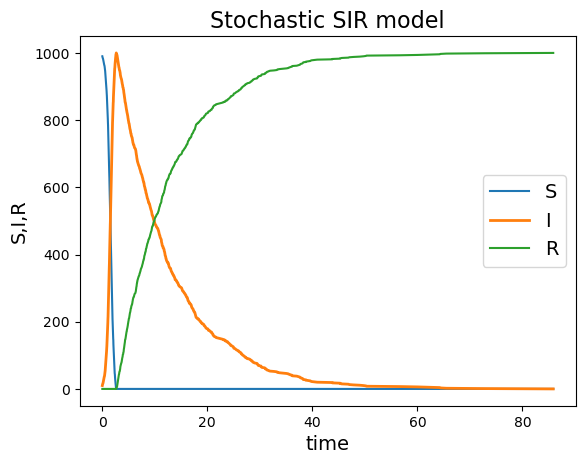

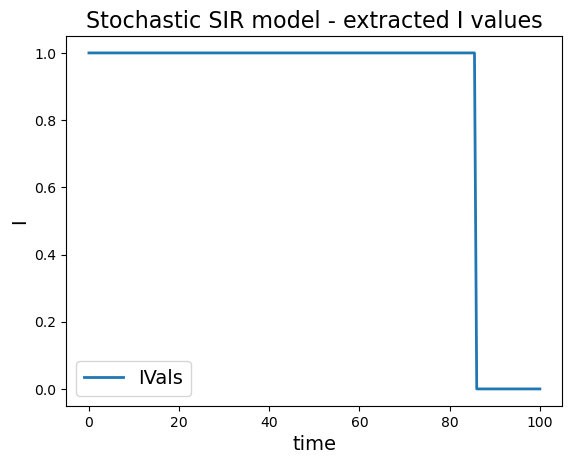

In [9]:
import numpy as np # Import NumPy library. The "np" bit tells Python to give NumPy the alias of np. So now we can call np. function_name rather than numpy.
import matplotlib.pyplot as plt

# Parameter values
beta = 3.0*10**-3
mu = 0.1

# Set up arrays to record event times, and values of S, I and R after after each event
SVec = np.array([])
IVec = np.array([])
RVec = np.array([])
tVec = np.array([])

# Set up an array to record pre-determined times and values of I at those times
tVals = np.array([i*0.5 for i in range(201)])
IVals = np.array([0 for i in range(201)])

# Set initial conditions and the initial time
S = 10**3 - 10
I = 10
R = 0
t = 0

IVals[0] = I

# Record initial conditions in the S, I, R and t arrays
SVec = np.append(SVec, S)
IVec = np.append(IVec, I)
RVec = np.append(RVec, R)
tVec = np.append(tVec, t)

while I > 0:
    
    previous_time = t
    
    r1 = np.random.uniform(0, 1, 1)
    totalRate = beta*I*S + mu*I
    t = t - (1/totalRate)*np.log(r1)
    
    new_time = t
    
    for i in range(201):
        if tVals[i] < new_time:
            IVals[i] = I
    
    r2 = np.random.uniform(0, 1, 1)
    if r2 < beta*I*S:
        S = S - 1
        I = I + 1
    else:
        I = I - 1
        R = R + 1
        
    SVec = np.append(SVec, S)
    IVec = np.append(IVec, I)
    RVec = np.append(RVec, R)
    tVec = np.append(tVec, t)

# plot the time evolution of the S, I, R
plt.plot(tVec, SVec, label = "S")
plt.plot(tVec, IVec, lw = 2, label = "I")
plt.plot(tVec, RVec, label = "R")

# labels etc
plt.xlabel("time", fontsize = 14)
plt.ylabel("S,I,R", fontsize = 14)
plt.title("Stochastic SIR model", fontsize = 16)
plt.legend(fontsize = 14)
plt.show()        

# plot the time evolution of I, as recorded in I_vals
plt.plot(tVals, IVals, lw = 2, label = "IVals")

# labels etc
plt.xlabel("time", fontsize = 14)
plt.ylabel("I", fontsize = 14)
plt.title("Stochastic SIR model - extracted I values", fontsize = 16)
plt.legend(fontsize = 14)
plt.show()


## Task A5. The probability of a major outbreak (worth approximately 12% of the marks)

**Assignment:** Run 1000 simulations of the stochastic SIR model, starting from a single infected individual (with the remainder of the population susceptible). Count the number of simulations in which the final value of $I+R$ exceeds 10 (i.e. the number for which $R>10$ when $I$ hits zero), and compare this to the analytic estimate for the "probability of a major outbreak" described in the Lecture.

Details: 
- Use the following parameter values for the baseline case (where time is again measured in days): $\beta = 3 \times 10^{-4}$, $\mu = 0.1$, $N = 10^{3}$.
- Recall from the lecture that the analytic estimate for the probability of a major outbreak is $p = 1 - \frac{1}{R_0}$, where $R_0 = \frac{\beta N}{\mu}$.
- Run 1000 simulations of the stochastic SIR model. Calculate (and print) the proportion of simulations in which the final value of $I+R$ exceeds 10.
- Calculate and print the analogous analytic estimate for the probability of a major outbreak.

- Hint: To run 1000 simulations of the stochastic SIR model, you will need to use a FOR loop. To run the simulations more quickly, you do not have to store the values of $t$, $S$, $I$ and $R$ after every event (instead, simply store the value of $I + R$ at the end of the simulation).

*Insert code and markdown cells below, as appropriate, in which to provide your response to this task.*

---

In [10]:
import numpy as np # Import NumPy library. 

# constants
beta = 3.0*10**-4
mu = 0.1
print(f'The number of outbreaks estimated by the analytic model is {round(1000*(1-mu/(beta*999)))}. ')
def SIR_simulator(N):
    IR_list = [] # keep track of IR_val over 1000 simulations
    for i in range(N):
        # Set up arrays to record event times, and values of S, I and R after after each event
        IR_val = 0 # reset IR value
        SVec = np.array([])
        IVec = np.array([])
        RVec = np.array([])
        tVec = np.array([])
        
        # Set initial conditions and the initial time
        S = 10**3 - 1
        I = 1
        R = 0
        t = 0
        
        # Record initial conditions in the S, I, R and t arrays
        SVec = np.append(SVec, S)
        IVec = np.append(IVec, I)
        RVec = np.append(RVec, R)
        tVec = np.append(tVec, t)
        
        # --- While the outbreak is ongoing (I > 0), generate events --- #
        count = 0
        while I > 0:
            #decide when the next event will happen
            r1 = np.random.uniform(0, 1, 1) 
            totalRate = beta*I*S + mu*I
            t = t - (1/totalRate)*np.log(r1)
            
            r2 = np.random.uniform(0, 1, 1) 
            #if the event is an 'infection event'
            if r2 < beta*I*S/totalRate:
                S = S - 1
                I = I + 1
            # if the event is a 'recovery event'
            else:
                I = I - 1
                R = R + 1
                
            SVec = np.append(SVec, S)
            IVec = np.append(IVec, I)
            RVec = np.append(RVec, R)
            tVec = np.append(tVec, t)
        #after 1 simulation complete, calculate I+R
        IR_val = IVec[-1] + RVec[-1]
        IR_list.append(IR_val)
    
    #count number of time outbreak is major (I+R>10)
    IR_count = 0
    for j in range(1000):
        if IR_list[j] > 10:
            IR_count+=1
    
    #print count, compare to analytic estimate for prob of major outbreak = 1- mu/beta*N
    return IR_count

stochastic = SIR_simulator(1000)

print(f'The number of outbreaks estimated by the stochastic model is {stochastic}. ')


The number of outbreaks estimated by the analytic model is 666. 
The number of outbreaks estimated by the stochastic model is 670. 


## Section B (worth approximately 40% of the marks)

## Task B1. Extensions
**Assignment:** Using Python, write code to complete the following exercises:

- Consider the variable $M$, which represents the total number of individuals ever infected over the entire course of a simulation of the stochastic SIR model (run until $I$ hits zero) - i.e. the final value of $I + R$. Plot a graph of ${\rm Prob}(M > m)$ as a function of $m$, for the default parameter values described in Task A5 above (compute the probability by running a large number of stochastic simulations and calculating the proportion of simulations in which $M>m$). Hint: You only have to run the simulations once (rather than running multiple simulations for each value of $m$).
- Add a vertical line to the plot marking the value of $m$ that corresponds to the (positive) solution to the "final size equation" described in the Lecture (note: you will have to look up an appropriate Python function to solve this equation numerically, as in Task A2 above).
- Now instead consider the stochastic SIS model described in the paper "Will an outbreak exceed available resources for control? Estimating the risk from invading pathogens using practical definitions of a severe epidemic" by Thompson, Gilligan and Cunniffe (https://royalsocietypublishing.org/doi/epdf/10.1098/rsif.2020.0690). The key difference between the stochastic SIR model and the stochastic SIS model is that, in the stochastic SIS model, individuals go back into the $S$ compartment when they recover (rather than entering the $R$ compartment). Pick either the "Final size" or "Duration" definition of a severe epidemic described in that paper, and write code to reproduce the relevant figure from that article using model simulations (either Fig 4a or Fig 4b; n.b. you are only required to reproduce the solid lines in the chosen figure). Hint: You do not have to simulate the model until $I$ hits zero to make this figure - that might take a very long time. Instead, you can stop each simulation as soon as the relevant maximum value on the x-axis is exceeded (or when $I$ hits zero, if that occurs first).
- Most of this Assignment involved using deterministic and stochastic versions of the basic SIR model. However, the SIR model is quite simple and does not include some important features that affect transmission of pathogens in the real world. Do some research into ways that the SIR model can be extended to include additional real-world realism. Write one or two paragraphs to summarise your findings (including noting some pathogens/diseases for which the extensions that you explain are appropriate).

*Insert code and markdown cells below, as appropriate, in which to provide your response to this task.*


---

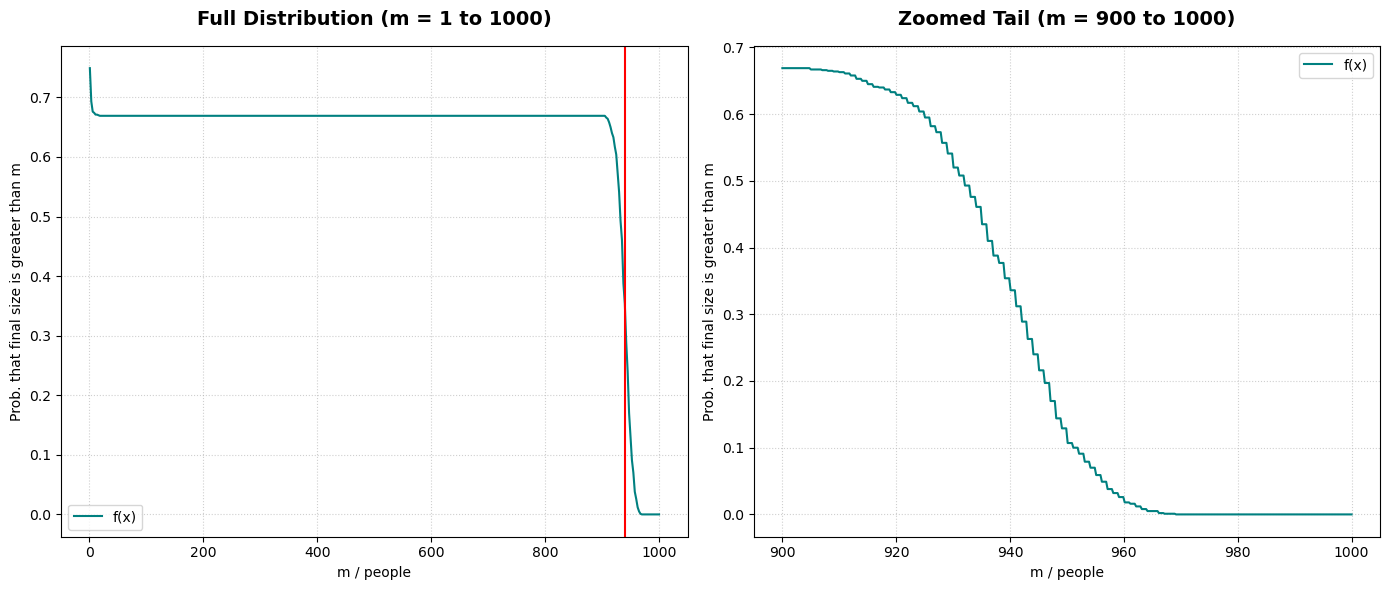

In [11]:
import numpy as np # Import NumPy library. 
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import fsolve


def f(x_array, IR_list):
    outbreaks = np.array(IR_list)
    results=[]
    for x_val in x_array:
        total = (x_val < outbreaks).sum()
        results.append(total / len(IR_list))
        
    return np.array(results)

def final_size_eq(x, N, beta, mu):
    return N - x - (N )*np.exp(-beta*x/mu)

# constants
beta = 3.0*10**-4
mu = 0.1

def SIR_simulator(N):
    IR_list = [] # keep track of IR_val over 1000 simulations
    for i in range(N):
        # Set up arrays to record event times, and values of S, I and R after after each event
        IR_val = 0 # reset IR value
        SVec = np.array([])
        IVec = np.array([])
        RVec = np.array([])
        tVec = np.array([])
        
        # Set initial conditions and the initial time
        S = 10**3 - 1
        I = 1
        R = 0
        t = 0
        
        # Record initial conditions in the S, I, R and t arrays
        SVec = np.append(SVec, S)
        IVec = np.append(IVec, I)
        RVec = np.append(RVec, R)
        tVec = np.append(tVec, t)
        
        # --- While the outbreak is ongoing (I > 0), generate events --- #
        count = 0
        while I > 0:
            #decide when the next event will happen
            r1 = np.random.uniform(0, 1, 1) 
            totalRate = beta*I*S + mu*I
            t = t - (1/totalRate)*np.log(r1)
            
            r2 = np.random.uniform(0, 1, 1) 
            #if the event is an 'infection event'
            if r2 < beta*I*S/totalRate:
                S = S - 1
                I = I + 1
            # if the event is a 'recovery event'
            else:
                I = I - 1
                R = R + 1
                
            SVec = np.append(SVec, S)
            IVec = np.append(IVec, I)
            RVec = np.append(RVec, R)
            tVec = np.append(tVec, t)
        #after 1 simulation complete, calculate I+R
        IR_val = IVec[-1] + RVec[-1]
        IR_list.append(IR_val)
    
    x = np.linspace(0, 1000, 400)

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))
    
    configs = [ 
        {"range": (1, 1000), "ax": ax1, "title": "Full Distribution (m = 1 to 1000)"}, 
        {"range": (900, 1000), "ax": ax2, "title": "Zoomed Tail (m = 900 to 1000)"} 
    ] 
    
    for config in configs: 
        ax = config["ax"] 
        start, end = config["range"] 
        
        # Generate data 
        x = np.linspace(start, end, 400) 
        ax.plot(x, f(x, IR_list), label='f(x)', color='teal') 
        # Set the Title and Labels 
        ax.set_title(config["title"], fontsize=14, fontweight='bold', pad=15) 
        ax.set_ylabel("Prob. that final size is greater than m") 
        ax.set_xlabel("m / people") 
        ax.legend() 
        ax.grid(True, linestyle=':', alpha=0.6) 
    
    plt.tight_layout()  
    x_sol = fsolve(final_size_eq, x0=N, args=(N,beta,mu)) 
    ax1.axvline(x_sol, color='red')
    
    plt.show()
    

SIR_simulator(1000)


# Epidemiology - Section B - Task 4: Extensions of the basic SIR Model for real-world realism

## Introduction  
The classic SIR model, as a fundamental framework in epidemiology, derives its simplicity from a series of important simplifying assumptions: a homogeneously mixed population, no age structure differences, no latent period, permanent immunity after recovery, no asymptomatic transmission, and no vaccination interventions. These assumptions make the model easy to analyse and calculate, but they also result in a significant gap from the complex and variable real world.

As we gradually incorporate these previously neglected factors into our research perspective—introducing age structure to characterise contact patterns among different groups, adding a latent period compartment (SEIR) to reflect the delayed transmission after infection, considering the contribution of asymptomatic carriers (SEIAR) to covert transmission, incorporating vaccination (SVIR) and immunity waning (SIRS) mechanisms—each extension transforms a former "assumption" into a "quantifiable variable for research". This process not only deepens our understanding of specific transmission mechanisms but also significantly enhances the credibility and predictive capability of the model.

**--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

## The classic SIR Model is a foundation, but real-world epidemics involve many additional complexities. Common extensions include:

1.**Latent period (SEIR Model):** An exposed(E) compartment is added for individuals who have been infected but are not yet infectious. This is crucial for diseases with a significant incubation period, such as COVID-19 or measles. The SEIR model better captures the delay between infection and the onset of infectiousness, which affects the timing of interventions.

Key parameter: The length of the incubation period directly affects the speed of the epidemic's development.  
**· Measles:** The average incubation period is **8 days**. The basic reproduction number is **R<sub>0</sub> $\approx$ 17**. The infectious period is **4 days**.       
**· COVID-19:** The average incubation period is **5.8 days**. The basic reproduction number is **R<sub>0</sub> $\approx$ 6.8**. The infectious period is **7 days**.    
**· Ebola:** The average incubation period is **9.3 days**. The basic reproduction number is **R<sub>0</sub> $\approx$ 1.6**. The infectious period is **21 days**.  
**· HIV:** The average incubation period is **87 days**. The basic reproduction number is **R<sub>0</sub> $\approx$ 2.2**. The infectious period is **42 days**.  

$$
\frac{dS}{dt} = -\frac{\beta S I}{N}
$$

$$
\frac{dE}{dt} = \frac{\beta S I}{N} - \sigma E
$$

$$
\frac{dI}{dt} = \sigma E - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

- $\beta$：Transmission rate (contact rate × probability of infection)
- $\sigma$：Incubation period countdown (1/number of days of incubation)
- $\gamma$：Recovery rate (1/infectious period days)

In [12]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [13]:
def SEIR(y, t, beta, sigma, gamma):
    S, E, I, R = y
    N = S + E + I + R
    dS = -beta * S * I / N
    dE = beta * S * I / N - sigma * E
    dI = sigma * E - gamma * I
    dR = gamma * I
    return [dS, dE, dI, dR]

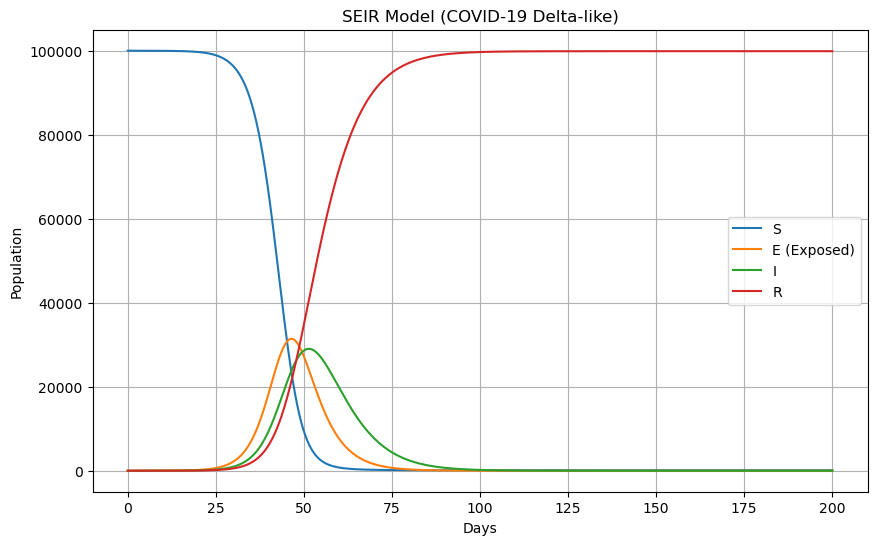

In [14]:
# Parameters 1 (COVID-19)
beta = 6.8 / 7        # R0 ≈ 6.8, Infectious period: 7 days
sigma = 1 / 5.8       # Incubation period: (5.8 days)^-1
gamma = 1 / 7         # Recovery rate: (7 days)^-1
N = 1e5
S0 = N - 1
E0 = 0
I0 = 1
R0 = 0
y0 = [S0, E0, I0, R0]
t = np.linspace(0, 200, 1000)

sol = odeint(SEIR, y0, t, args=(beta, sigma, gamma))
S, E, I, R = sol.T
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='S')
plt.plot(t, E, label='E (Exposed)')
plt.plot(t, I, label='I')
plt.plot(t, R, label='R')
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SEIR Model (COVID-19 Delta-like)')
plt.legend()
plt.grid()
plt.show()

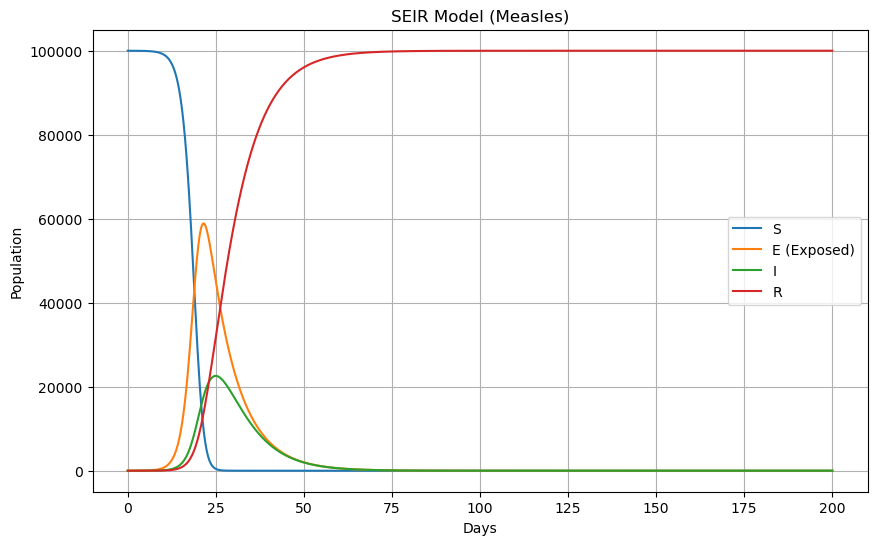

In [15]:
# Parameters 2 (Measles)
beta = 17 / 4        # R0 ≈ 17, Infectious period: 4 days
sigma = 1 / 8        # Incubation period: (8 days)^-1
gamma = 1 / 4        # Recovery rate: (4 days)^-1
N = 1e5
S0 = N - 1
E0 = 0
I0 = 1
R0 = 0
y0 = [S0, E0, I0, R0]
t = np.linspace(0, 200, 1000)

sol = odeint(SEIR, y0, t, args=(beta, sigma, gamma))
S, E, I, R = sol.T
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='S')
plt.plot(t, E, label='E (Exposed)')
plt.plot(t, I, label='I')
plt.plot(t, R, label='R')
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SEIR Model (Measles)')
plt.legend()
plt.grid()
plt.show()

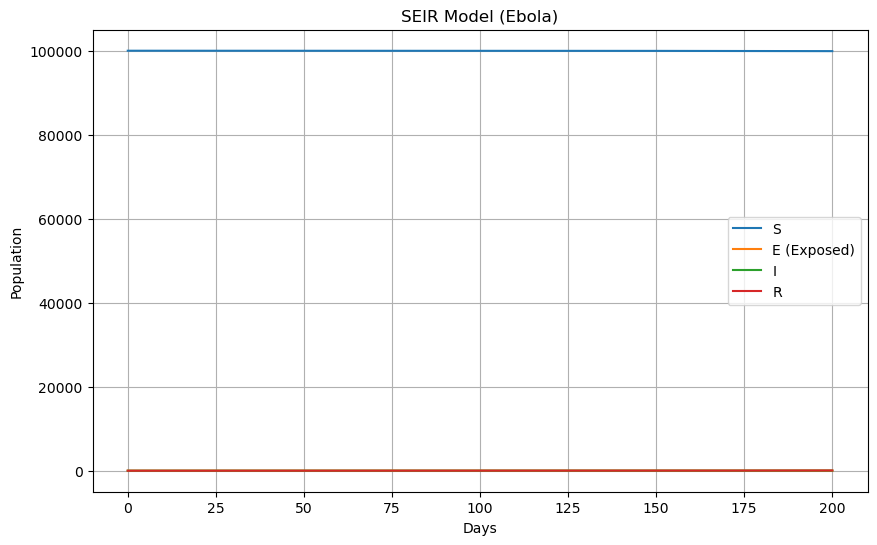

In [16]:
# Parameters 3 (Ebola)
beta = 1.6 / 21        # R0 ≈ 1.6, Infectious period: 21 days
sigma = 1 / 9.3        # Incubation period: (9.3 days)^-1
gamma = 1 / 21         # Recovery rate: (21 days)^-1
N = 1e5
S0 = N - 1
E0 = 0
I0 = 1
R0 = 0
y0 = [S0, E0, I0, R0]
t = np.linspace(0, 200, 1000)

sol = odeint(SEIR, y0, t, args=(beta, sigma, gamma))
S, E, I, R = sol.T
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='S')
plt.plot(t, E, label='E (Exposed)')
plt.plot(t, I, label='I')
plt.plot(t, R, label='R')
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SEIR Model (Ebola)')
plt.legend()
plt.grid()
plt.show()

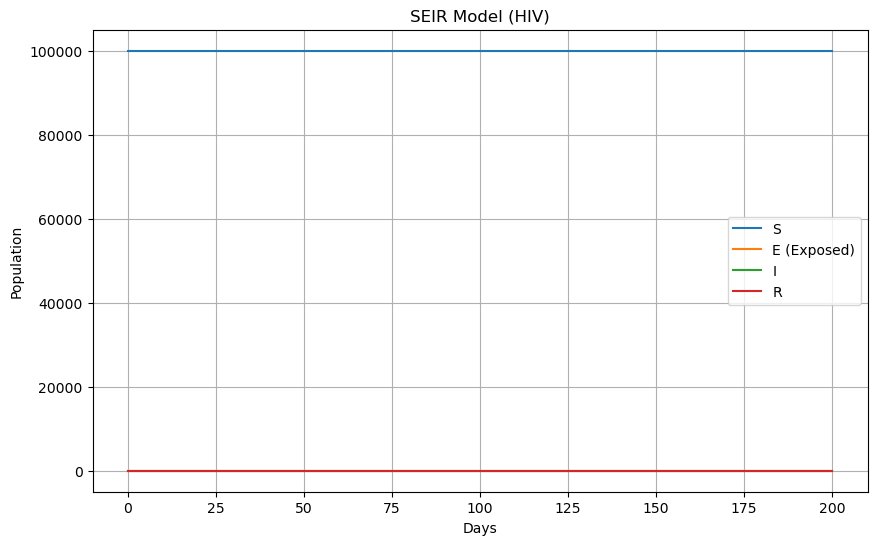

In [17]:
# Parameters 4 (HIV)
beta = 2.2 / 42        # R0 ≈ 2.2, Infectious period: 42 days
sigma = 1 / 87         # Incubation period: (87 days)^-1
gamma = 1 / 42         # Recovery rate: (42 days)^-1
N = 1e5
S0 = N - 1
E0 = 0
I0 = 1
R0 = 0
y0 = [S0, E0, I0, R0]
t = np.linspace(0, 200, 1000)

sol = odeint(SEIR, y0, t, args=(beta, sigma, gamma))
S, E, I, R = sol.T
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='S')
plt.plot(t, E, label='E (Exposed)')
plt.plot(t, I, label='I')
plt.plot(t, R, label='R')
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SEIR Model (HIV)')
plt.legend()
plt.grid()
plt.show()

2.**Waning immunity and reinfection (SIRS Model):** For pathogens like pertussis or some coronviruses, immunity is not lifelong. Compartments for waning immunity allow individuals to become susceptible again after recovery.

Key parameter: Duration of immunity  
**· Seasonal flu:** The basic reproduction number is **R<sub>0</sub> $\approx$ 1.4**. The infectious period is **5 days**. The duration of immunity is **365 days**.  
**· RSV Respiratory syncytial virus:** The basic reproduction number is **R<sub>0</sub> $\approx$ 2.5**. The infectious period is **7 days**. The duration of immunity is **90 days**.

$$
\frac{dS}{dt} = -\frac{\beta SI}{N} + \xi R
$$

$$
\frac{dI}{dt} = \frac{\beta SI}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I - \xi R
$$


- $\beta$：Transmission rate
- $\gamma$: Recovery rate
- $\xi$：Rate of immune loss (1/the duration of immunity)

In [18]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [19]:
def SIRS(y, t, beta, gamma, xi):
    S, I, R = y
    N = S + I + R
    dS = -beta * S * I / N + xi * R
    dI = beta * S * I / N - gamma * I
    dR = gamma * I - xi * R
    return [dS, dI, dR]

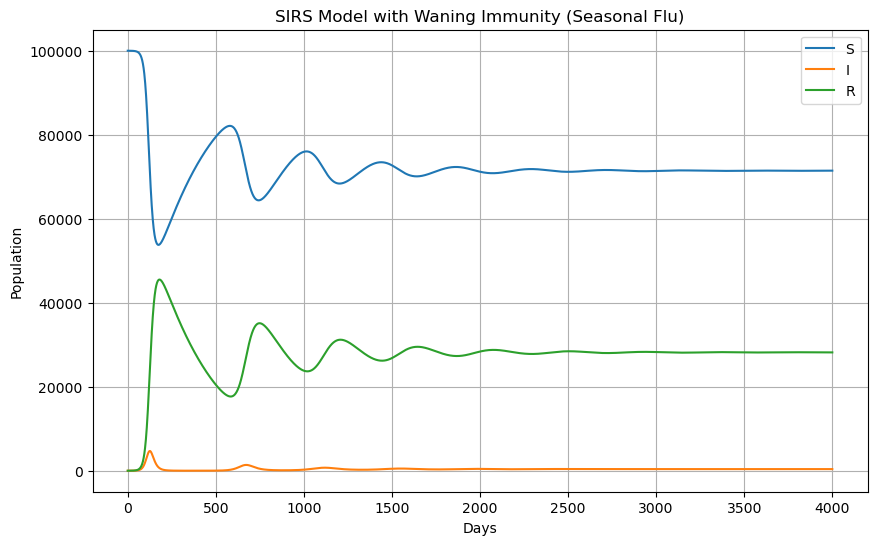

In [20]:
# Parameter 1 (Seasonal flu)
beta = 1.4 / 5        # R0 ≈ 1.4, Infectious period: 5 days
gamma = 1 / 5         # Recovery rate: (5 days)^-1 
xi = 1 / 365          # Rate of immune loss: (365 days)^-1
N = 1e5
S = N - 1
I = 1
R = 0
y = [S, I, R]
t = np.linspace(0, 4000, 4000)

sol = odeint(SIRS, y, t, args=(beta, gamma, xi))
S, I, R = sol.T

plt.figure(figsize=(10,6))
plt.plot(t, S, label='S')
plt.plot(t, I, label='I')
plt.plot(t, R, label='R')
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SIRS Model with Waning Immunity (Seasonal Flu)')
plt.legend()
plt.grid()
plt.show()

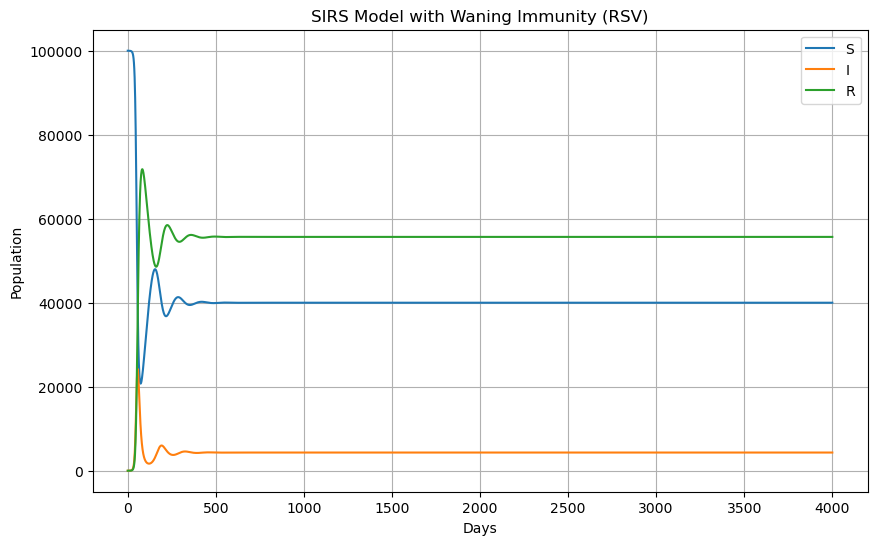

In [21]:
# Parameter 2 (RSV Respiratory syncytial virus)
beta = 2.5 / 7        # R0 ≈ 2.5, Infectious period: 7 days
gamma = 1 / 7         # Recovery rate: (7 days)^-1 
xi = 1 / 90           # Rate of immune loss: (90 days)^-1
N = 1e5
S = N - 1
I = 1
R = 0
y = [S, I, R]
t = np.linspace(0, 4000, 4000)

sol = odeint(SIRS, y, t, args=(beta, gamma, xi))
S, I, R = sol.T

plt.figure(figsize=(10,6))
plt.plot(t, S, label='S')
plt.plot(t, I, label='I')
plt.plot(t, R, label='R')
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SIRS Model with Waning Immunity (RSV)')
plt.legend()
plt.grid()
plt.show()

3.**Vaccination/Immunisation Chamber (SVIR Model):** Vaccination and immunisation chambers have been established to indicate people who have been vaccinated and are no longer spreading disease.

Key parameter: Compartment(V) - People who have been vaccinated and have entered the immunisation chamber.  
**· COVID-19:** The basic reproduction number is **R<sub>0</sub> $\approx$ 6.8**. The infectious period is **7 days**. Proportion of daily vaccinations among susceptible individuals is **1%**

$$
\frac{dS}{dt} = -\frac{\beta SI}{N} - \nu(t)S
$$

$$
\frac{dV}{dt} = \nu(t)S - \frac{\beta VI}{N}
$$

$$
\frac{dI}{dt} = \frac{\beta(S + V)I}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

- $\beta$：Transmission rate
- $\gamma$: Recovery rate
- $\nu(t)$：Vaccination rate (can be set to non-zero only during specific periods)

In [22]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [23]:
def SVIR(y, t, beta, gamma, nu, vacc_start, vacc_end):
    S, V, I, R = y
    N = S + V + I + R
    vacc = nu if vacc_start <= t <= vacc_end else 0.0
    dS = -beta * S * I / N - vacc * S
    dV = vacc * S - beta * V * I / N
    dI = beta * (S + V) * I / N - gamma * I
    dR = gamma * I
    return [dS, dV, dI, dR]

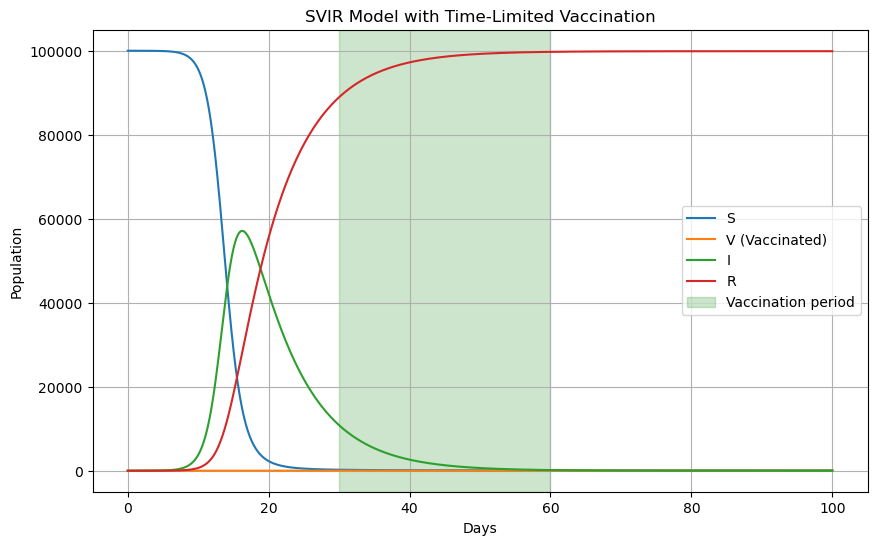

In [24]:
beta = 6.8 / 7        # R0 ≈ 6.8, Infectious period: 7 days
gamma = 1 / 7         # Recovery rate: (7 days)^-1
nu = 0.01
N = 1e5
S = N - 1
V = 0
I = 1
R = 0
y = [S, V, I, R]
t = np.linspace(0, 100, 1000)

sol = odeint(SVIR, y, t, args=(beta, gamma, nu, 30, 60))
S, V, I, R = sol.T

plt.figure(figsize=(10,6))
plt.plot(t, S, label='S')
plt.plot(t, V, label='V (Vaccinated)')
plt.plot(t, I, label='I')
plt.plot(t, R, label='R')
plt.axvspan(30, 60, alpha=0.2, color='green', label='Vaccination period')
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SVIR Model with Time-Limited Vaccination')
plt.legend()
plt.grid()
plt.show()

4.**Age structure and social mixing:** Populations can be divided into age groups with different contact rates. For example, children may have more contacts and be more susceptible to influenza or chickenpox. Age-structured models help design age-targeted vaccination campaigns.

Key paramters: Divide the crowd into different age groups. The infection and recovery rates for different age groups.  
**· COVID-19:** The infectious period is **7 days**.  

Thought: Divide the population into $n$ age groups，the population of each group is $N_i$. For the $i$ group，we track its susceptible individuals $S_i$, infected individuals $I_i$ and recovered individuals $R_i$（or more compartments like incubation period $E_i$. The population $$N = \sum_{i=1}^n N_i$$.
$$
\frac{dS_i}{dt} = -\sum_j \beta_{ij} S_i I_j / N_j
$$

$$
\frac{dI_i}{dt} = \sum_j \beta_{ij} S_i I_j / N_j - \gamma I_i
$$

- $\lambda_i(t)$ is the probability of individuals in group $i$ being infected per unit time. It is contributed collectively by infected individuals from all groups：

$$
\lambda_i(t) = \sum_{j=1}^n \beta_{ij} \frac{I_j}{N_j}
$$


- $\lambda_i(t)$：Infectiousness of individuals in group $i$ at time $t$
- $\beta_{ij}$：The number of effective infections a single infected individual in group $j$ causes to each susceptible individual in group $i$ per day
- $I_j$：Number of infected people in group $j$
- $N_j$: The total population of group $j$ 
- $n$：The total population

In [25]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [26]:
def age_SIR(y, t, beta_mat, gamma, n_groups, N_init):
    S = y[0:n_groups]
    I = y[n_groups:2*n_groups]
    R = y[2*n_groups:3*n_groups]
    dS = np.zeros(n_groups)
    dI = np.zeros(n_groups)
    dR = np.zeros(n_groups)
    
    # Calculate infection pressure
    lambda_i = np.zeros(n_groups)
    for i in range(n_groups):
        for j in range(n_groups):
            lambda_i[i] += beta_mat[i, j] * I[j] / N_init[j]
    
    for i in range(n_groups):
        dS[i] = -lambda_i[i] * S[i]
        dI[i] = lambda_i[i] * S[i] - gamma * I[i]
        dR[i] = gamma * I[i]
    
    return np.concatenate([dS, dI, dR])

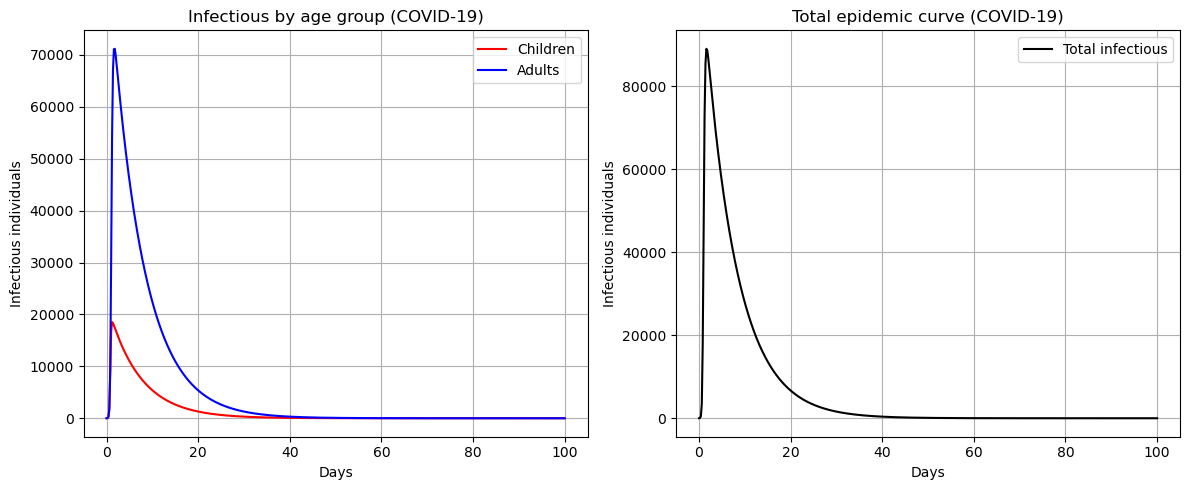

In [27]:
# Parameter 1 (Take two different age groups and COVID-19 as an example)
n_groups = 2
N_init = [20000, 80000]                   # 20000 children, 80000 adults
gamma = 1 / 7                             # Recovery rate: (7 days)^-1 

# Contact matrix (unit: effective contacts per day, but the data is for reference only)
beta_mat = np.array([[10.0, 1.0],
                     [1.0, 5.0]])

I0 = [5, 5]
S0 = [N_init[0] - I0[0], N_init[1] - I0[1]]
R0 = [0, 0]

y0 = np.concatenate([S0, I0, R0])
t = np.linspace(0, 100, 500)   

sol = odeint(age_SIR, y0, t, args=(beta_mat, gamma, n_groups, N_init))
S = sol[:, 0:n_groups]
I = sol[:, n_groups:2*n_groups]
R = sol[:, 2*n_groups:3*n_groups]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(t, I[:,0], 'r-', label='Children')
plt.plot(t, I[:,1], 'b-', label='Adults')
plt.xlabel('Days')
plt.ylabel('Infectious individuals')
plt.title('Infectious by age group (COVID-19)')
plt.legend()
plt.grid()
plt.subplot(1,2,2)
plt.plot(t, I[:,0] + I[:,1], 'k-', label='Total infectious')
plt.xlabel('Days')
plt.ylabel('Infectious individuals')
plt.title('Total epidemic curve (COVID-19)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

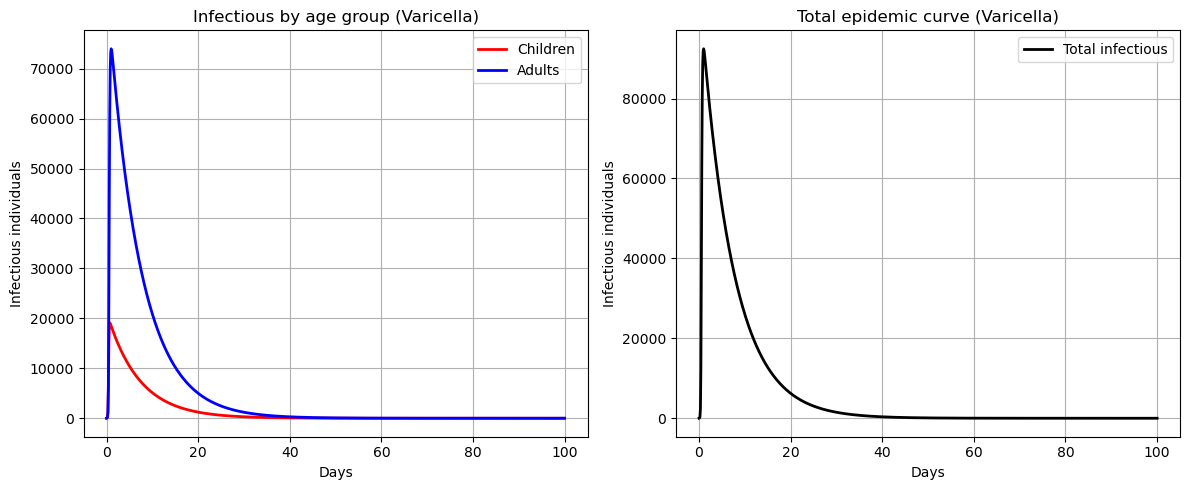

In [28]:
# Parameter 2 (Take two different age groups and Varicella as an example)
n_groups = 2
N_init = [20000, 80000]                        # 20000 children, 80000 adults
gamma = 1 / 7                                  # Recovery rate: (7 days)^-1 

# Contact matrix (unit: effective contacts per day, but the data is for reference only)
beta_mat = np.array([[18.0, 3.0],   
                     [3.0, 6.0]])

I0 = [5, 5]
S0 = [N_init[0] - I0[0], N_init[1] - I0[1]]
R0 = [0, 0]
y0 = np.concatenate([S0, I0, R0])

t = np.linspace(0, 100, 1000)  


sol = odeint(age_SIR, y0, t, args=(beta_mat, gamma, n_groups, N_init))
S = sol[:, 0:n_groups]
I = sol[:, n_groups:2*n_groups]
R = sol[:, 2*n_groups:3*n_groups]


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(t, I[:,0], 'r-', linewidth=2, label='Children')
plt.plot(t, I[:,1], 'b-', linewidth=2, label='Adults')
plt.xlabel('Days')
plt.ylabel('Infectious individuals')
plt.title('Infectious by age group (Varicella)')
plt.legend()
plt.grid()
plt.subplot(1,2,2)
plt.plot(t, I[:,0] + I[:,1], 'k-', linewidth=2, label='Total infectious')
plt.xlabel('Days')
plt.ylabel('Infectious individuals')
plt.title('Total epidemic curve (Varicella)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

5.**Spatial structure and mobility:** Metapopulation models or network models account for movement between regions or heterogeneous contact patterns. They are essential for diseases like Ebola, where local outbreaks and travel play major roles.

Thought: Divide the total population into several subpopulations (such as cities), describe each subpopulation with the SIR model, and add **human flow movement** between subpopulations (such as commuting rates). Here is a simplest **two-city model** presented, where the population is coupled through commuting.

$$
\frac{dS_1}{dt} = -\frac{\beta S_1 I_1}{N_1} + m_{21} S_2 - m_{12} S_1
$$

- $\beta$: Transmission rate
- $\gamma$: Recovery rate
- $m_{12}$: The daily migration rate from City 1 to City 2
- $m_{21}$: The daily migration rate from City 2 to City 1

All variable names with the suffix "1" represent the data of City 1, and all variable names with suffix "2" represent the data of City 2.

In [29]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [30]:
def two_city_SIR(y, t, beta, gamma, m12, m21, N1, N2):
    S1, I1, R1, S2, I2, R2 = y
    # City 1
    dS1 = -beta * S1 * I1 / N1 - m12 * S1 + m21 * S2
    dI1 = beta * S1 * I1 / N1 - gamma * I1 - m12 * I1 + m21 * I2
    dR1 = gamma * I1 - m12 * R1 + m21 * R2
    # City 2
    dS2 = -beta * S2 * I2 / N2 + m12 * S1 - m21 * S2
    dI2 = beta * S2 * I2 / N2 - gamma * I2 + m12 * I1 - m21 * I2
    dR2 = gamma * I2 + m12 * R1 - m21 * R2
    return [dS1, dI1, dR1, dS2, dI2, dR2]

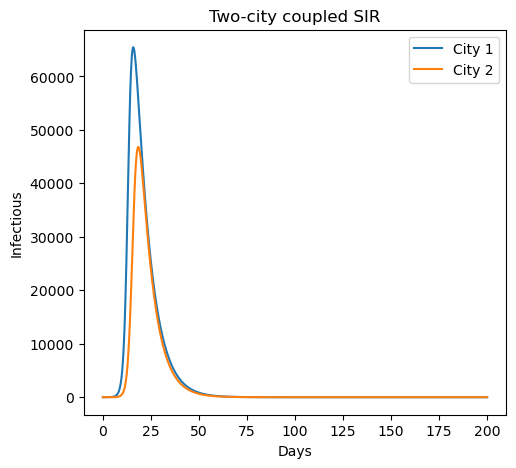

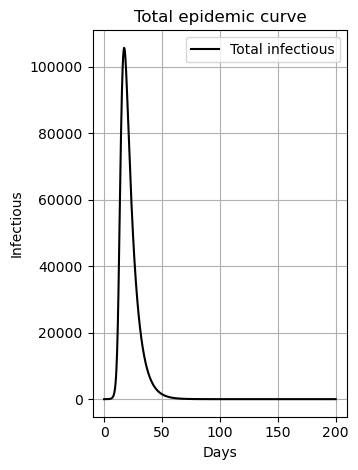

In [31]:
# Parameter 1 (COVID-19)
beta = 6.8 / 7                                # Suppose the transmission rates in the two cities are both equal to 6.8 / 7 
gamma = 1 / 7                                 # Suppose the recovery rates in the two cities are both equal to 1 / 7
m12 = 0.02                                    # Suppose the daily migration rate from City 1 to City 2 equals to 2%
m21 = 0.03                                   # Suppose the daily migration rate from City 2 to City 1 equals to 3%
N1, N2 = 1e5, 1e5                             # Suppose the initial populations of the two cities are 100000 and 100000 respectively
S1_0, I1_0, R1_0 = N1 - 1, 1, 0 
S2_0, I2_0, R2_0 = N2, 0, 0                   # Suppose that City 2 was initially free of infection
y0 = [S1_0, I1_0, R1_0, S2_0, I2_0, R2_0]
t = np.linspace(0, 200, 1000)

sol = odeint(two_city_SIR, y0, t, args=(beta, gamma, m12, m21, N1, N2))
S1, I1, R1, S2, I2, R2 = sol.T

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(t, I1, label='City 1')
plt.plot(t, I2, label='City 2')
plt.xlabel('Days')
plt.ylabel('Infectious')
plt.title('Two-city coupled SIR')
plt.legend()
plt.show()

plt.subplot(1,2,2)
plt.plot(t, I1 + I2, 'k-', label='Total infectious')
plt.xlabel('Days')
plt.ylabel('Infectious')
plt.title('Total epidemic curve')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

6.**Asymptomatic and presymptomatic transmission (SEIAR)**: Many diseases can be spread by individuals who are not showing symptoms. Extending the model to include asymptomatic compartments is vital for understanding silent spread and the effectiveness of testing.

Key parameters: Proportion of asymptomatic cases  
**· COVID-19:** The symptomatic transmission rate is **1.9**. The asymptomatic transmission rate is **0.9**. The symptomatic and asymptomatic infectious period is **7 days**. The average incubation period is **5.8 days**. The proportion of asymptomatic cases is **40%**.

$$
\frac{dS}{dt} = -\frac{S}{N} \left( \beta_s I_s + \beta_a I_a \right)
$$

$$
\frac{dE}{dt} = \frac{S}{N} \left( \beta_s I_s + \beta_a I_a \right) - \sigma E
$$

$$
\frac{dI_s}{dt} = (1 - p) \sigma E - \gamma_s I_s
$$

$$
\frac{dI_a}{dt} = p \sigma E - \gamma_a I_a
$$

$$
\frac{dR}{dt} = \gamma_s I_s + \gamma_a I_a
$$

- $\beta_s$: Symptomatic transmission rate
- $\beta_a$: Asymptomatic transmission rate
- $\gamma_s$: Symptomatic recovery rate
- $\gamma_a$: Asymptomatic recovery rate
- $\sigma$：Incubation period countdown (1/number of days of incubation)
- $p$: Proportion of asymptomatic cases

All variable names with the suffix "s" represent the data of symptomatic patients, and all variable names with suffix "a" represent the data of asymptomatic patients.

In [32]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [33]:
def SEIAR(y, t, beta_s, beta_a, sigma, gamma_s, gamma_a, p):
    S, E, I_s, I_a, R = y
    N = S + E + I_s + I_a + R
    inf_rate = (beta_s * I_s + beta_a * I_a) * S / N
    dS = -inf_rate
    dE = inf_rate - sigma * E
    dI_s = (1-p) * sigma * E - gamma_s * I_s
    dI_a = p * sigma * E - gamma_a * I_a
    dR = gamma_s * I_s + gamma_a * I_a
    return [dS, dE, dI_s, dI_a, dR]

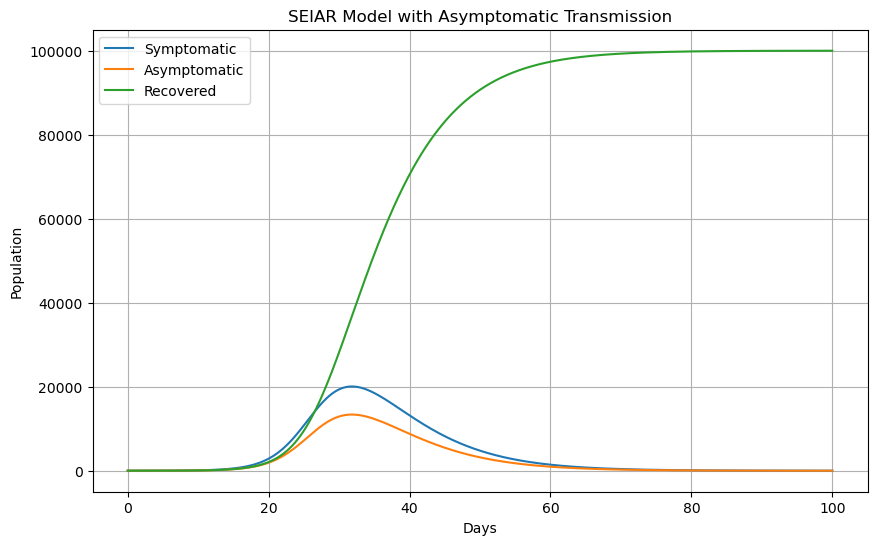

In [34]:
# Parameter 1 (Take COVID-19 as an example)
beta_s = 1.9                            # Suppose the symptomatic transmission rate is 1.9
beta_a = 0.9                            # Suppose the asymptomatic transmission rate is 0.9
sigma = 1 / 5.8                         # Suppose the incubation period is (5.8 days)^-1
gamma_s = 1 / 7                         
gamma_a = 1 / 7                         # Suppose the symptomatic recovery rate and the asymptomatic recovery rate are both equal to (7 days)^-1              
p = 0.4                                 # Suppose the proportion of asymptomatic cases is 40%
N = 1e5
S0 = N - 10
E0 = 0
I_s0 = 5
I_a0 = 5
R0 = 0
y0 = [S0, E0, I_s0, I_a0, R0]
t = np.linspace(0, 100, 1000)

sol = odeint(SEIAR, y0, t, args=(beta_s, beta_a, sigma, gamma_s, gamma_a, p))
S, E, I_s, I_a, R = sol.T

plt.figure(figsize=(10,6))
plt.plot(t, I_s, label='Symptomatic')
plt.plot(t, I_a, label='Asymptomatic')
plt.plot(t, R, label='Recovered')
plt.xlabel('Days')
plt.ylabel('Population')
plt.title('SEIAR Model with Asymptomatic Transmission')
plt.legend()
plt.grid()
plt.show()

7.**A combination of many variables of the former**: Including incubation period, asymptomatic transmission, vaccination, waning immunity and the age structure.

Key parameters: i).**V**：Those who have been vaccinated    ii).**E**: Exposed(incubation period)    iii).**$I_s$**: Symptomatic infected individuals    iv).**$I_a$**：Asymptomatic infected individuals    v).**S**: Susceptible    vi).**R**：Recoverees (whose immunity gradually fades over time and returns to the S)  
**· COVID-19:** The average incubation period is **5.8 days**. The basic reproduction number is **R<sub>0</sub> $\approx$ 6.8**. The symptomatic and asymptomatic infectious periods are **9 days** and **7 days**. Proportion of daily vaccinations among susceptible individuals is **1%**.

-**Total infection pressure** (Infectivity of individuals in group $i$ over $t$ days):
$$
\lambda_i(t) = \sum_{j=1}^n \beta_{ij} \frac{I_{s,j} + \alpha I_{a,j}}{N_j^{\text{curr}}}
$$

- $\alpha$：Relative infectivity of asymptomatic carriers
- $N_j^{\text{curr}}$：Current total population of group $j$ (changing slowly over time)

$$
N_j^{\text{curr}} = S_j + V_j + E_j + I_{s,j} + I_{a,j} + R_j
$$

-**System of differential equations** (For each age group $i = 1, 2, ..., n$):
$$
\frac{dS_i}{dt} = -\lambda_i S_i + \xi R_i - \nu_i(t) S_i
$$

$$
\frac{dV_i}{dt} = \nu_i(t) S_i - (1 - VE) \lambda_i V_i
$$

$$
\frac{dE_i}{dt} = \lambda_i S_i + (1 - VE) \lambda_i V_i - \sigma E_i
$$

$$
\frac{dI_{s,i}}{dt} = (1 - p) \sigma E_i - \gamma_s I_{s,i}
$$

$$
\frac{dI_{a,i}}{dt} = p \sigma E_i - \gamma_a I_{a,i}
$$

$$
\frac{dR_i}{dt} = \gamma_s I_{s,i} + \gamma_a I_{a,i} - \xi R_i
$$

-$\sigma$: Incubation period countdown (1/Incubation period)  
-$p$: Proportion of asymptomatic carriers   
-$\gamma_s$: Recovery rate of symptomatic infected individuals   
-$\gamma_a$: Recovery rate of asymptomatic carriers (usually equal to $\gamma_s$)  
-$\xi$: Rate of immune loss (1/Duration of immunity)  
-$\nu_i(t)$: Vaccination rate of group $i$ (can be set to non-zero only during specific periods)   
-$VE$: Vaccine efficacy（0~1），The probability of infection for vaccinated individuals is reduced by a factor of $(1-VE)$   
-$\alpha$: Relative infectiousness of asymptomatic carriers (compared with symptomatic carriers)   
-$\beta_{ij}$: Transmission rate (contact matrix) from group $j$ to group $i$ 

In [35]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [36]:
def integrated_age_model(y, t, beta_mat, sigma, gamma_s, gamma_a, p, alpha,
                         xi, vacc_rate, vacc_start, vacc_end, ve, n_groups):
    n_compart = 6                      # Number of Immunisation Chamber per group
    S = y[0::n_compart]
    V = y[1::n_compart]
    E = y[2::n_compart]
    I_s = y[3::n_compart]
    I_a = y[4::n_compart]
    R = y[5::n_compart]
    N_curr = S + V + E + I_s + I_a + R
    
    lambda_i = np.zeros(n_groups)
    for i in range(n_groups):
        for j in range(n_groups):
            lambda_i[i] += beta_mat[i, j] * (I_s[j] + alpha * I_a[j]) / N_curr[j]
    
    # Vaccine switch
    vacc_on = 1.0 if vacc_start <= t <= vacc_end else 0.0
    
    dS = np.zeros(n_groups)
    dV = np.zeros(n_groups)
    dE = np.zeros(n_groups)
    dI_s = np.zeros(n_groups)
    dI_a = np.zeros(n_groups)
    dR = np.zeros(n_groups)
    
    for i in range(n_groups):
        dS[i] = -lambda_i[i] * S[i] + xi * R[i] - vacc_rate * vacc_on * S[i]
        dV[i] = vacc_rate * vacc_on * S[i] - (1 - ve) * lambda_i[i] * V[i]
        dE[i] = lambda_i[i] * S[i] + (1 - ve) * lambda_i[i] * V[i] - sigma * E[i]
        dI_s[i] = (1 - p) * sigma * E[i] - gamma_s * I_s[i]
        dI_a[i] = p * sigma * E[i] - gamma_a * I_a[i]
        dR[i] = gamma_s * I_s[i] + gamma_a * I_a[i] - xi * R[i]
  
    dy = np.zeros_like(y)
    
    for i in range(n_groups):
        idx = i * n_compart
        dy[idx:idx+n_compart] = [dS[i], dV[i], dE[i], dI_s[i], dI_a[i], dR[i]]
    return dy

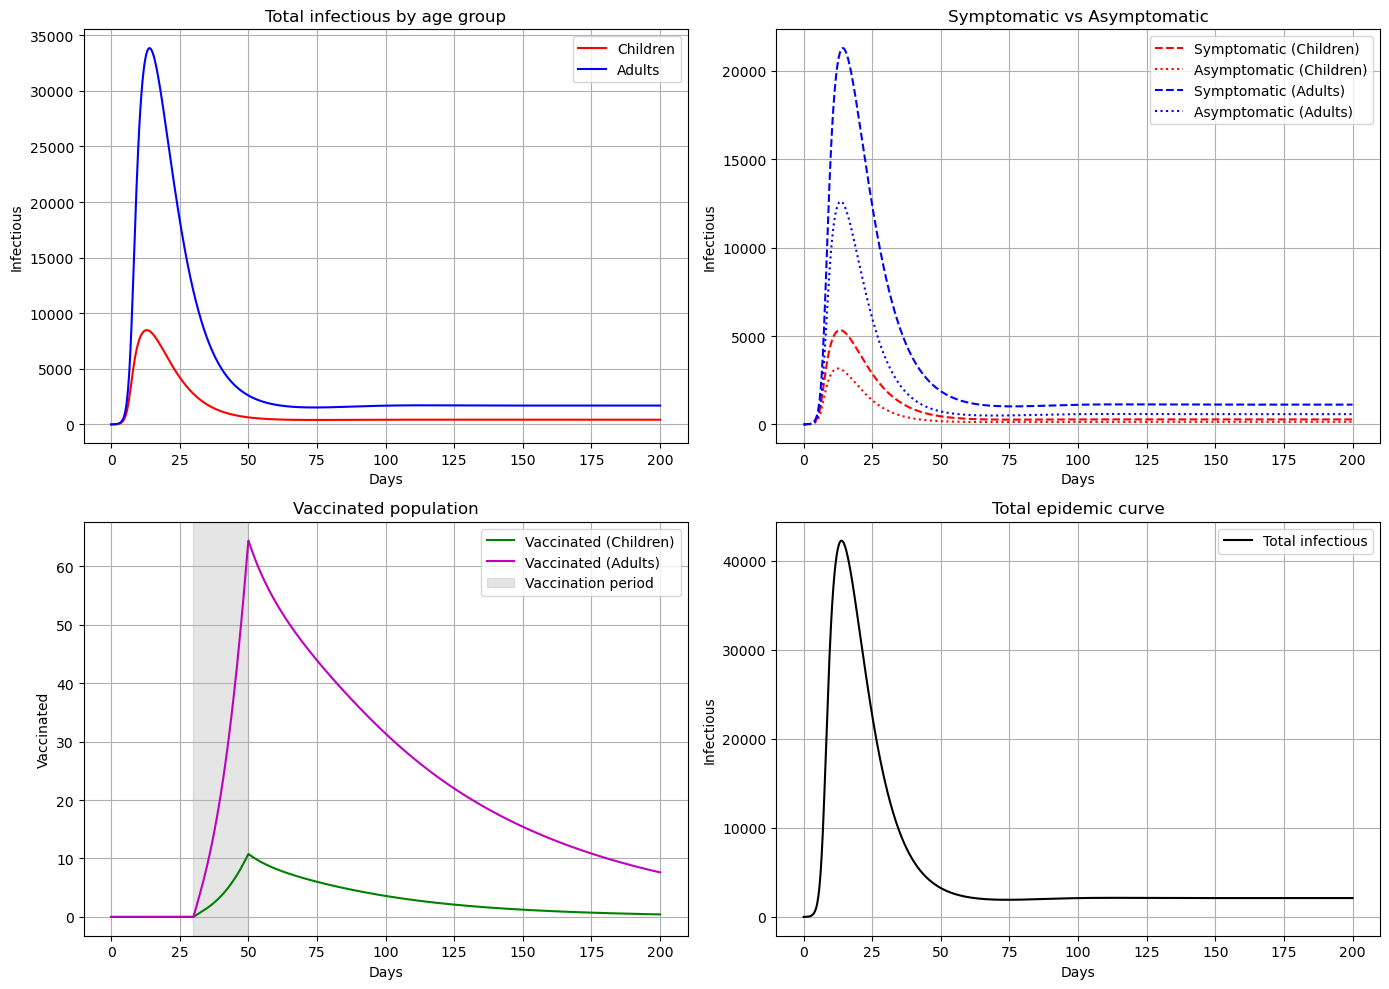

In [37]:
# Parameter (Take COVID-19 as an example)
n_groups = 2                                            # Two age groups: children and adults
N_init = [20000, 80000]
beta_mat = np.array([[10.0, 2.0],
                     [2.0, 6.0]])
sigma = 1 / 5.8          # Incubation period: (5.8 days)^-1
gamma_s = 1 / 9        # Symptomatic recovery rate: (9 days)^-1
gamma_a = 1 / 7        # Asymptomatic recovery rate: (7 days)^-1
p = 0.4                # Proportion of asymptomatic cases: 40%
alpha = 0.5            # Relative infectiousness when asymptomatic (half that of symptomatic cases)
xi = 1 / 365           # Immune system decline (assuming it lasts for a year)
vacc_rate = 0.01       # 1% of susceptibles are vaccinated daily
vacc_start = 30        # Vaccination starts on day 30
vacc_end = 50          # Vaccination starts on day 60
ve = 0.9               # Vaccine effectiveness: 90%

# Initial conditions: Each group has 5 initial infected individuals (symptomatic), 0 asymptomatic individual
I_s0 = [5, 5]
I_a0 = [0, 0]
E0 = [0, 0]
R0 = [0, 0]
V0 = [0, 0]
S0 = [N_init[0] - I_s0[0], N_init[1] - I_s0[1]]

y0 = []
for i in range(n_groups):
    y0.extend([S0[i], V0[i], E0[i], I_s0[i], I_a0[i], R0[i]])
y0 = np.array(y0)

t = np.linspace(0, 200, 1000)  

sol = odeint(integrated_age_model, y0, t,
             args=(beta_mat, sigma, gamma_s, gamma_a, p, alpha,
                   xi, vacc_rate, vacc_start, vacc_end, ve, n_groups))

n_compart = 6
S_res = sol[:, 0::n_compart]
V_res = sol[:, 1::n_compart]
E_res = sol[:, 2::n_compart]
I_s_res = sol[:, 3::n_compart]
I_a_res = sol[:, 4::n_compart]
R_res = sol[:, 5::n_compart]
total_inf = I_s_res + I_a_res

plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
plt.plot(t, total_inf[:,0], 'r-', label='Children')
plt.plot(t, total_inf[:,1], 'b-', label='Adults')
plt.xlabel('Days')
plt.ylabel('Infectious')
plt.title('Total infectious by age group')
plt.legend()
plt.grid()
plt.subplot(2,2,2)
plt.plot(t, I_s_res[:,0], 'r--', label='Symptomatic (Children)')
plt.plot(t, I_a_res[:,0], 'r:', label='Asymptomatic (Children)')
plt.plot(t, I_s_res[:,1], 'b--', label='Symptomatic (Adults)')
plt.plot(t, I_a_res[:,1], 'b:', label='Asymptomatic (Adults)')
plt.xlabel('Days')
plt.ylabel('Infectious')
plt.title('Symptomatic vs Asymptomatic')
plt.legend()
plt.grid()
plt.subplot(2,2,3)
plt.plot(t, V_res[:,0], 'g-', label='Vaccinated (Children)')
plt.plot(t, V_res[:,1], 'm-', label='Vaccinated (Adults)')
plt.axvspan(vacc_start, vacc_end, alpha=0.2, color='gray', label='Vaccination period')
plt.xlabel('Days')
plt.ylabel('Vaccinated')
plt.title('Vaccinated population')
plt.legend()
plt.grid()
plt.subplot(2,2,4)
plt.plot(t, total_inf[:,0] + total_inf[:,1], 'k-', label='Total infectious')
plt.xlabel('Days')
plt.ylabel('Infectious')
plt.title('Total epidemic curve')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Data Source

## A.COVID-19
**1.The basic reproduction number: R<sub>0</sub> $\approx$ 6.8** -- Li, Q., et al. (2020). Early transmission dynamics in Wuhan, China, of novel coronavirus–infected pneumonia. New England Journal of Medicine, 382(13), 1199-1207.  

**2.Infectious period: 7 days** -- World Health Organization. (2020). Report of the WHO-China Joint Mission on Coronavirus Disease 2019 (COVID-19).  

**3.Incubation period: 5.8 days** -- Lauer, S. A., et al. (2020). The incubation period of coronavirus disease 2019 (COVID-19) from publicly reported confirmed cases: estimation and application. Annals of Internal Medicine, 172(9), 577-582.  

**4.Asymptomatic proportion: 40%** -- Oran, D. P., & Topol, E. J. (2021). The proportion of SARS-CoV-2 infections that are asymptomatic: a systematic review. Annals of Internal Medicine, 174(5), 655-662.  

**5.Asymptomatic relative transmissibility: 0.5** -- Buitrago-Garcia, D., et al. (2020). Occurrence and transmission potential of asymptomatic and presymptomatic SARS-CoV-2 infections: A living systematic review and meta-analysis. PLoS Medicine, 17(9), e1003346.

**6.Duration of immunity after infection: 365 days** -- Dan, J. M., et al. (2021). Immunological memory to SARS-CoV-2 assessed for up to 8 months after infection. Science, 371(6529), eabf4063.

**7.Vaccine effectiveness: 90%** -- Polack, F. P., et al. (2020). Safety and efficacy of the BNT162b2 mRNA Covid-19 vaccine. New England Journal of Medicine, 383(27), 2603-2615.  

**8.Daily vaccination rate: 1%** -- Our World in Data. (2021). Coronavirus (COVID-19) Vaccinations.  

**9.Symptomatic transmission rate: 1.9** -- Li, Q., et al. (2020). Early transmission dynamics in Wuhan, China, of novel coronavirus–infected pneumonia. New England Journal of Medicine, 382(13), 1199-1207.  

**10.Asymptomatic transmission rate: 0.9** -- Buitrago-Garcia, D., et al. (2020). Occurrence and transmission potential of asymptomatic and presymptomatic SARS-CoV-2 infections: A living systematic review and meta-analysis. PLoS Medicine, 17(9), e1003346.

## B.Measles
**1.The basic reproduction number: R<sub>0</sub> $\approx$ 17** -- Guerra, F. M., et al. (2017). The basic reproduction number (R0) of measles: a systematic review. The Lancet Infectious Diseases, 17(12), e420-e428.  

**2.Incubation period: 8 days** -- Centers for Disease Control and Prevention. (2021). Epidemiology and Prevention of Vaccine-Preventable Diseases (Pink Book). 14th ed.

**3.Infectious period: 4 days** -- Moss, W. J., & Griffin, D. E. (2012). Measles. The Lancet, 379(9811), 153-164.

## C.Ebola
**1.The basic reproduction number: R<sub>0</sub> $\approx$ 1.6** -- Khan, A., et al. (2015). Estimating the basic reproductive ratio for the Ebola outbreak in Liberia and Sierra Leone. Infectious Diseases of Poverty, 4(1), 13.  

**2.Incubation period: 9.3 days** -- WHO Ebola Response Team. (2014). Ebola virus disease in West Africa—the first 9 months of the epidemic and forward projections. New England Journal of Medicine, 371(16), 1481-1495.  

**3.Infectious period: 21 days** -- Legrand, J., et al. (2007). Understanding the dynamics of Ebola epidemics. Epidemiology & Infection, 135(4), 610-621.

## D.HIV
**1.The basic reproduction number: R<sub>0</sub> $\approx$ 2.2** -- Hollingsworth, T. D., et al. (2008). HIV-1 transmission, by stage of infection. The Journal of Infectious Diseases, 198(5), 687-693.  

**2.Incubation period: 87 days** -- Fiebig, E. W., et al. (2003). Dynamics of HIV viremia and antibody seroconversion in plasma donors: implications for diagnosis and staging of primary HIV infection. AIDS, 17(13), 1871-1879.  

**3.Infectious period: 42 days** -- Pinkerton, S. D. (2008). Probability of HIV transmission during acute infection in Rakai, Uganda. AIDS and Behavior, 12(5), 677-684.

## E.Seasonal flu
**1.The basic reproduction number: R<sub>0</sub> $\approx$ 1.4** -- Biggerstaff, M., et al. (2014). Estimates of the reproduction number for seasonal, pandemic, and zoonotic influenza: a systematic review of the literature. BMC Infectious Diseases, 14(1), 480.  

**2.Infectious period: 5 days** -- Carrat, F., et al. (2008). Time lines of infection and disease in human influenza: a review of volunteer challenge studies. American Journal of Epidemiology, 167(7), 775-785.  

**3.Duration of immunity: 365 days** -- Couch, R. B., & Kasel, J. A. (1983). Immunity to influenza in man. Annual Review of Microbiology, 37(1), 529-549.

## F.RSV (Respiratory syncytial virus)
**1.The basic reproduction number: R<sub>0</sub> $\approx$ 2.5** -- Reis, J., & Shaman, J. (2016). Retrospective parameter estimation and forecast of respiratory syncytial virus in the United States. PLoS Computational Biology, 12(10), e1005133.  

**2.Infectious period: 7 days** -- Hall, C. B., et al. (2013). Respiratory syncytial virus. In Viral Infections of Humans (pp. 731-760). Springer, Boston, MA.  

**3.Duration of immunity: 90 days** -- Openshaw, P. J., & Chiu, C. (2013). Protective and dysregulated T cell immunity in RSV infection. Current Opinion in Virology, 3(4), 468-474.

**--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Outroducton
We must recognise that even after integrating all the above factors, the model remains a simplification of reality. For example, there are still numerous complex variables in the real world such as spatial heterogeneity (population migration, cross-regional spread), dynamic behavioural changes (fluctuations in public protective awareness, adjustments in government intervention measures), pathogen evolution (changes in transmission characteristics due to viral mutations), and socio-economic factors (distribution of medical resources, differences in population density). These factors still exist in the current model in the form of "assumptions".  

Therefore, the extended study of the SIR model is essentially a journey of exploration from "idealised assumptions" towards "complex reality". Each extension narrows the gap between the model and reality, while also revealing more variables that require research. It is precisely this never-ending process of approximation that drives the development of epidemiological modelling theory and provides increasingly precise scientific evidence for public health decision-making.

## Notes about this submission

You will submit a single Jupyter notebook for this project assignment (this notebook, with your additions).

- The last thing you should do before submitting the notebook is to Restart Kernel and Run All Cells. You should then save the notebook and submit the .ipynb file. **You will lose marks if you submit a notebook that has not been run.**

- You are expected to add code and markdown cells to this document as appropriate to provide your responses to the tasks. However, throughout this assignment, please do use the deterministic and stochastic SIR model codes from the Epidemiology I and Epidemiology II code notebooks as required (i.e., you are supposed to copy that code across and adapt it, rather than start coding from scratch).

- This assignment lends itself to producing a nice document. A good guide for what the final notebook should be like is: if the notebook is run and all code cells and task descriptions are collapsed, the notebook should be readable as a short report, primarily consisting of a short introduction to each section followed by figures and descriptions of the figures.

- Use the comments in the "Epidemiology I code" notebook as a guide to the level of code commenting expected. Each code cell should begin with a comment line or lines concisely stating what the cell is for (alternatively, precede the code cell with a markdown cell explaining what you are about to do). Functions should have comments describing what they do. It can be assumed that the reader understands Python to a basic level (e.g. comments like "Create an array" or "Make a plot" on every line are unnecessary). Add comments to set off blocks of code or to note anything tricky.

---